In [1]:
# Dataset citation: SDGClassification Benchmark, benchmark.csv, distributed by the SDGClassification project. Source repository: https://github.com/SDGClassification/benchmark (as identified in ../SDGClassification Benchmark/README.md).

In [ ]:
# Imports and simple EDA helpers
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_ROOT = Path("..")

def inspect_table(df, name, preview_columns=None):
    print(f"\n{name}: {len(df):,} rows x {len(df.columns):,} columns")
    cols = preview_columns or list(df.columns[:8])
    shown = df[cols]
    display(pd.DataFrame({"column": shown.columns, "dtype": [str(x) for x in shown.dtypes],
                          "missing": shown.isna().sum().values,
                          "missing_%": (shown.isna().mean().values * 100).round(2),
                          "unique": shown.astype(str).nunique(dropna=True).values}))
    print(f"Duplicate rows on shown columns: {shown.astype(str).duplicated().sum():,}")
    display(shown.head(5))

def plot_counts(counts, title, xlabel="Class", ylabel="Rows"):
    counts = counts.sort_index()
    display(counts.rename("count").to_frame())
    ax = counts.plot(kind="bar", figsize=(11, 4), color="#4472C4")
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def text_stats(df, column):
    if column not in df.columns:
        return
    values = df[column].fillna("").astype(str)
    lengths = values.str.len()
    words = values.str.split().str.len()
    print(f"\nText field: {column}")
    display(pd.DataFrame({"characters": lengths.describe(), "words": words.describe()}))
    print("Empty text rows:", int(values.str.strip().eq("").sum()))

In [ ]:
# Load data
path = DATA_ROOT / "SDGClassification Benchmark/benchmark.csv"
df = pd.read_csv(path, low_memory=False)

In [ ]:
#Table and missing values
inspect_table(df, "SDGClassification Benchmark", ["id", "text", "sdg", "label"])


SDGClassification Benchmark: 1,251 rows x 4 columns


,column,dtype,missing,missing_%,unique
0,id,object,0,0.0,1251
1,text,object,0,0.0,1247
2,sdg,int64,0,0.0,17
3,label,bool,0,0.0,2


Duplicate rows on shown columns: 0


,id,text,sdg,label
0,bf90734,Many people feel insecure in their homes and c...,1,False
1,88729bd,The prevailing assumption in the public choice...,1,False
2,5c55ba8,They are also subject to an ecological relatio...,1,False
3,256ffa0,"Rafael Di Telia, Sebastian Edwards and Emesto ...",1,False
4,04e9948,The average supply of calories for food consum...,1,False


,count
sdg,
1,77
2,69
3,76
4,82
5,69
6,85
7,100
8,74
9,57


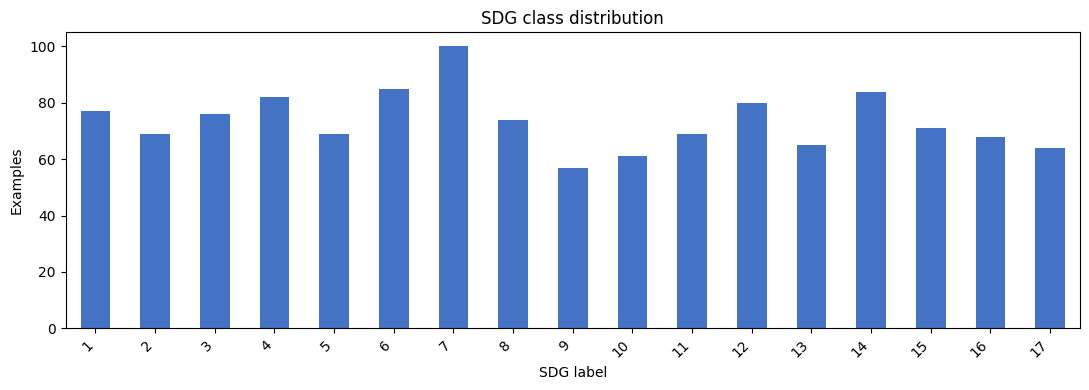

In [ ]:
# Class distribution
plot_counts(df["sdg"].value_counts(dropna=False), "SDG class distribution", "SDG label", "Examples")

In [ ]:
# Binary label counts
display(df["label"].value_counts(dropna=False).to_frame("rows"))

,rows
label,
False,635
True,616


In [ ]:
# Text length
text_stats(df, "text")


Text field: text


,characters,words
count,1251.000000,1251.000000
mean,603.841727,90.839329
std,203.020414,29.964815
min,301.000000,28.000000
25%,446.500000,68.000000
50%,563.000000,85.000000
75%,724.000000,110.000000
max,1287.000000,202.000000


Empty text rows: 0
